<a href="https://colab.research.google.com/github/Neilburt5/SPRO2/blob/main/Embbeded_assitant.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Thesis project: Fine-tuning Large Language Models for Specialized Assistance in Embedded Systems Engineering**
*Neil Burt Martin*





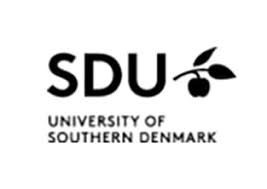


## Prepare enviroment:


In [ ]:
%%capture

#Install standart Python modules, PyTorch and xFormers
import os, re
import torch; v = re.match(r"[0-9\.]{3,}", str(torch.__version__)).group(0)
xformers = "xformers==" + ("0.0.32.post2" if v == "2.8.0" else "0.0.29.post3")

# Install dependencies, HuggingFace utilities and Unsloth newest version
!pip install --no-deps bitsandbytes accelerate {xformers} peft trl triton cut_cross_entropy unsloth_zoo
!pip install sentencepiece protobuf "datasets>=3.4.1,<4.0.0" "huggingface_hub>=0.34.0" hf_transfer
!pip install "unsloth[colab-new]@ git+https://github.com/unslothai/unsloth.git"

## Install Base Model: *Mistral 7b* (v0.3)

In [ ]:
#FastLanguageModel handles memory-efficient loading,quantization
from unsloth import FastLanguageModel
import torch
#Max number of tokens set to 4096,set the best data type for the GPU, load the model in 4-bit quantization
max_seq_length =4096
dtype = None
load_in_4bit = True
#Load Mistral form unsloth model hub
model, tokenizer =FastLanguageModel.from_pretrained(
    model_name= "unsloth/mistral-7b-v0.3",
    max_seq_length=max_seq_length,
    dtype=dtype,
    load_in_4bit=load_in_4bit,
)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2025.12.9: Fast Mistral patching. Transformers: 4.57.3.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.741 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.9.0+cu126. CUDA: 7.5. CUDA Toolkit: 12.6. Triton: 3.5.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/4.14G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/157 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/587k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/446 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

## LoRA Hyperparameters:



In [ ]:
#Set LoRA hyperparameters
model= FastLanguageModel.get_peft_model(
    model,
    r=32,
    target_modules=["q_proj","k_proj","v_proj","o_proj","gate_proj","up_proj","down_proj"],
    lora_alpha=32,
    lora_dropout=0,
    bias="none",
    use_gradient_checkpointing="unsloth",
    random_state=3407,
    use_rslora=False,
    loftq_config=None,
    )

Unsloth 2025.12.9 patched 32 layers with 32 QKV layers, 32 O layers and 32 MLP layers.


## Format and Import Dataset

In [ ]:
#Define the structure of the training examples
alpaca_prompt="""Below is an instruction that describes a task, paired with an input that provides further context. Write a response to solve this task
###Instruction:
{}

### Input:
{}

###Response:
{}"""
#Define a special token that marks the end of a dull training example
EOS_TOKEN = tokenizer.eos_token
#Formats the structure to match with the dataset
def formatting_prompts_func(examples):
  instructions= examples["question"]
  inputs = examples.get("input", [""] * len(examples["question"])) # Handle missing 'input' key
  outputs=examples["answer"]
  texts=[]
  for instruction, input, output in zip(instructions,inputs,outputs):
    text=alpaca_prompt.format(instruction,input,output)+EOS_TOKEN
    texts.append(text)
  return{"text":texts,}

#Import dataset
import json
from datasets import Dataset

with open("/content/Dataset.json", "r") as f:
    data = json.load(f)
dataset = dataset.train_test_split(test_size=0.1, seed=42)
#Split dataset into train and test batches for futures evaluation
train_dataset = dataset["train"]
eval_dataset  = dataset["test"]
#Convert into a proper HuggingFace dataset
processed_data = {}

if data:
    keys = data[0].keys()
    for key in keys:
        processed_data[key] = [d[key] for d in data]

dataset = Dataset.from_dict(processed_data)
dataset=dataset.map(formatting_prompts_func,batched=True)

Map:   0%|          | 0/1651 [00:00<?, ? examples/s]

## Create trainer:

In [ ]:
#Import SFTTrainer (Supervised Fine-Tuning Trainer)
from trl import SFTTrainer, SFTConfig
from unsloth import is_bfloat16_supported
import torch
#Pass the LoRA-wrapped model, the tokenizer & the dataset. Set various training parameters
trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    train_dataset=dataset,
    eval_dataset=eval_dataset,
    dataset_text_field="text",
    max_seq_length=max_seq_length,
    packing=False,
    args = SFTConfig(
    per_device_train_batch_size=3,
    gradient_accumulation_steps=4,
    warmup_steps=5,
    max_steps=500,
    learning_rate=3e-4,

    logging_steps=10,
    log_level="info",

    eval_strategy="steps",
    eval_steps=50,

    fp16=not is_bfloat16_supported(),
    bf16=is_bfloat16_supported(),

    optim="adamw_8bit",
    weight_decay=0.01,
    lr_scheduler_type="linear",

    report_to="none",
    output_dir="outputs",
    dataset_num_proc=1,
),

)


Unsloth: Tokenizing ["text"]:   0%|          | 0/1651 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"]:   0%|          | 0/166 [00:00<?, ? examples/s]

max_steps is given, it will override any value given in num_train_epochs
Using auto half precision backend


## Train and plot statistics:

In [ ]:
trainer_stats=trainer.train()


The model is already on multiple devices. Skipping the move to device specified in `args`.
The following columns in the Training set don't have a corresponding argument in `PeftModelForCausalLM.forward` and have been ignored: id, attention_mask, question, answer, text. If id, attention_mask, question, answer, text are not expected by `PeftModelForCausalLM.forward`,  you can safely ignore this message.
skipped Embedding(32768, 4096, padding_idx=770): 128.0M params
skipped: 128.0M params
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 1,651 | Num Epochs = 4 | Total steps = 500
O^O/ \_/ \    Batch size per device = 3 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (3 x 4 x 1) = 12
 "-____-"     Trainable parameters = 83,886,080 of 7,331,909,632 (1.14% trained)


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss,Validation Loss
50,0.622000,0.556030
100,0.605600,0.453177
150,0.364100,0.339714
200,0.356400,0.300782
250,0.360500,0.237538
300,0.187400,0.174770
350,0.191400,0.141582
400,0.186100,0.129291
450,0.106400,0.106411
500,0.104400,0.098972


The following columns in the Evaluation set don't have a corresponding argument in `PeftModelForCausalLM.forward` and have been ignored: id, attention_mask, question, answer, text. If id, attention_mask, question, answer, text are not expected by `PeftModelForCausalLM.forward`,  you can safely ignore this message.

***** Running Evaluation *****
  Num examples = 166
  Batch size = 4
Unsloth: Not an error, but MistralForCausalLM does not accept `num_items_in_batch`.
Using gradient accumulation will be very slightly less accurate.
Read more on gradient accumulation issues here: https://unsloth.ai/blog/gradient
The following columns in the Evaluation set don't have a corresponding argument in `PeftModelForCausalLM.forward` and have been ignored: id, attention_mask, question, answer, text. If id, attention_mask, question, answer, text are not expected by `PeftModelForCausalLM.forward`,  you can safely ignore this message.

***** Running Evaluation *****
  Num examples = 166
  Batch size = 

## Inference model:

In [ ]:
FastLanguageModel.for_inference(model)
inputs=tokenizer(
    [
        alpaca_prompt.format(
            "Answer to the following question as an embbeded assistant", #instruction
            "Can I use a ultrasonic sensor to control the LEDs?",#input
            "", #output
        )
    ],return_tensors="pt").to("cuda")
outputs=model.generate(**inputs,use_cache=True)
tokenizer.batch_decode(outputs)

['<s> Below is an instruction that describes a task, paired with an input that provides further context. Write a response to solve this task\n###Instruction:\nAnswer to the following question as an embbeded assistant\n\n### Input:\nCan I use a ultrasonic sensor to control the LEDs?\n\n###Response:\nCan I use a ultrasonic sensor to control the LEDs?\n\n###Response:\nCan I use a ultrasonic sensor to control the LEDs?\n\n###Response:\nCan I use a ultrasonic sensor to control the LEDs?\n\n###Response:\nCan I use a ultrasonic sensor to control the LEDs?\n\n###Response:\nCan I use a ultrasonic sensor to control the LEDs?\n\n###Response:\nCan I use a ultrasonic sensor to control the LEDs?\n\n###Response:\nCan I use a ultrasonic sensor to control the LEDs?\n\n###Response:\nCan I use a ultrasonic sensor to control the LEDs?\n\n###Response:\nCan I use a ultrasonic sensor to control the LEDs?\n\n###Response:\nCan I use a ultrasonic sensor to control the LEDs?\n\n###Response:\nCan I use a ultrason

## Save model


In [ ]:
#Save LoRA adapters weights
model.save_pretrained("lora_model")
#Store tokenizer
tokenizer.save_pretrained("lora_model")


('lora_model/tokenizer_config.json',
 'lora_model/special_tokens_map.json',
 'lora_model/tokenizer.model',
 'lora_model/added_tokens.json',
 'lora_model/tokenizer.json')

## Export Model

In [ ]:
# Import the userdata module to access Colab secrets
from google.colab import userdata

# Retrieve the Hugging Face token from Colab secrets
HF_TOKEN = userdata.get('HF_TOKEN')

# Check if the token was retrieved successfully
if HF_TOKEN is None:
    print("Error: Hugging Face token (HF_TOKEN) not found in Colab secrets. Please add it.")
else:
    # Save to 8bit Q8_0 and push to Hugging Face Hub
    # Replace 'hf/model' with 'your_username/your_model_name' on Hugging Face
    if True: model.save_pretrained_gguf("model", tokenizer)
    if True: model.push_to_hub_gguf("Neilburt/embbeded_assistant", tokenizer, token=HF_TOKEN)

Unsloth: Merging model weights to 16-bit format...
Found HuggingFace hub cache directory: /root/.cache/huggingface/hub
Checking cache directory for required files...
Cache check failed: model-00001-of-00003.safetensors not found in local cache.
Not all required files found in cache. Will proceed with downloading.
Checking cache directory for required files...
Cache check failed: tokenizer.model not found in local cache.
Not all required files found in cache. Will proceed with downloading.


Unsloth: Merging weights into 16bit: 100%|██████████| 3/3 [01:49<00:00, 36.38s/it]


Unsloth: Merge process complete. Saved to `/content/model`
Unsloth: Converting to GGUF format...
==((====))==  Unsloth: Conversion from HF to GGUF information
   \\   /|    [0] Installing llama.cpp might take 3 minutes.
O^O/ \_/ \    [1] Converting HF to GGUF f16 might take 3 minutes.
\        /    [2] Converting GGUF f16 to ['q8_0'] might take 10 minutes each.
 "-____-"     In total, you will have to wait at least 16 minutes.

Unsloth: llama.cpp found in the system. Skipping installation.
Unsloth: Preparing converter script...
Unsloth: [1] Converting model into f16 GGUF format.
This might take 3 minutes...
Unsloth: Initial conversion completed! Files: ['mistral-7b-v0.3.F16.gguf']
Unsloth: [2] Converting GGUF f16 into q8_0. This might take 10 minutes...
Unsloth: Model files cleanup...
Unsloth: All GGUF conversions completed successfully!
Generated files: ['mistral-7b-v0.3.Q8_0.gguf']
Unsloth: No Ollama template mapping found for model 'unsloth/mistral-7b-v0.3'. Skipping Ollama Modelfil

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Checking cache directory for required files...
Cache check failed: model-00001-of-00003.safetensors not found in local cache.
Not all required files found in cache. Will proceed with downloading.
Checking cache directory for required files...
Cache check failed: tokenizer.model not found in local cache.
Not all required files found in cache. Will proceed with downloading.


...

Unsloth: Merge process complete. Saved to `/tmp/unsloth_gguf_nbqo3cvq`
Unsloth: Converting to GGUF format...
==((====))==  Unsloth: Conversion from HF to GGUF information
   \\   /|    [0] Installing llama.cpp might take 3 minutes.
O^O/ \_/ \    [1] Converting HF to GGUF f16 might take 3 minutes.
\        /    [2] Converting GGUF f16 to ['q8_0'] might take 10 minutes each.
 "-____-"     In total, you will have to wait at least 16 minutes.

Unsloth: llama.cpp found in the system. Skipping installation.
Unsloth: Preparing converter script...
Unsloth: [1] Converting model into f16 GGUF format.
This might take 3 minutes...
Unsloth: Initial conversion completed! Files: ['mistral-7b-v0.3.F16.gguf']
Unsloth: [2] Converting GGUF f16 into q8_0. This might take 10 minutes...
Unsloth: Model files cleanup...
Unsloth: All GGUF conversions completed successfully!
Generated files: ['mistral-7b-v0.3.Q8_0.gguf']
Unsloth: No Ollama template mapping found for model 'unsloth/mistral-7b-v0.3'. Skipping Oll

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  mistral-7b-v0.3.Q8_0.gguf   :   0%|          |  551kB / 7.70GB            

Uploading config.json...
Unsloth: Successfully uploaded GGUF to https://huggingface.co/Neilburt/embbeded_assistant
Unsloth: Cleaning up temporary files...
